# Task 2: Generative Model Baseline (No RAG)

Measure the quality of answers generated by phi3:mini and qwen2.5:1.5b without any retrieval context. 

This establishes the baseline against which RAG improvements are measured in Tasks 3 and 4.

In [1]:
# import sys
# !{sys.executable} -m pip install openai

In [4]:
import sys
sys.path.insert(0, '..')
sys.path.insert(0, '.')

import pandas as pd
import matplotlib.pyplot as plt
from openai import OpenAI
import time

from eval_utils import load_questions, run_generation_experiment, print_summary

questions = load_questions(deduplicate=True)
print(f'Questions to evaluate: {len(questions["Question"].unique())}')

Questions to evaluate: 627


In [5]:
class QAGeneratorNoRAG:
    """
    Standalone LLM generator (no context provided).
    """
    def __init__(self, model: str = 'phi3:mini', temperature: float = 0.3):
        self.model = model
        self.client = OpenAI(api_key='ollama', base_url='http://localhost:11434/v1')
        self.temperature = temperature

    def generate_answer(self, query: str, context: list = None) -> str:
        response = self.client.chat.completions.create(
            model=self.model,
            temperature=self.temperature,
            max_tokens=120,
            messages=[
                {
                    'role': 'system',
                    # No context instruction aka pure standalone generation
                    'content': 'Provide clear, concise, and full-sentence answers.',
                },
                {'role': 'user', 'content': f'Question: {query}'},
            ],
        )
        time.sleep(1) 
        return response.choices[0].message.content.strip()

In [6]:
# Run baseline for both models
baseline_results = {}

for model_name in ['phi3:mini', 'qwen2.5:1.5b']:
    print(f'\nRunning baseline for {model_name}...')
    generator = QAGeneratorNoRAG(model=model_name)
    results = run_generation_experiment(
        questions_df=questions,
        generator=generator,
        context_fn=None, # no RAG
        sleep_sec=0,
    )
    results.to_csv(f'results_task2_{model_name.replace(":", "_")}.csv', index=False)
    baseline_results[model_name] = results
    print_summary(f'{model_name} (no RAG)', results, 'transformer_match')

print('\nDone! Results saved to CSV.')


Running baseline for phi3:mini...
Using device: cpu


Loading weights: 100%|██████████| 393/393 [00:00<00:00, 6581.13it/s]


Error on: (NNP Harding #)(NNP Death )))(PP (IN in )(NP (NP (NN office ... -> object of type 'float' has no len()
Error on: According to Reader's Digest, is Finland best for living?... -> RobertaTokenizer has no attribute encode_plus
Error on: Adams ' opponents were what?... -> RobertaTokenizer has no attribute encode_plus
Error on: Are Count Volta 's original instruments and papers on displa... -> object of type 'float' has no len()
Error on: Are Kangaroos Shy?... -> object of type 'float' has no len()
Error on: Are Native Ghanaian languages divided into two linguistic su... -> object of type 'float' has no len()
Error on: Are Various sporting events popular in Finland ?... -> object of type 'float' has no len()
Error on: Are Various trees claimed to be " the " apple tree which New... -> object of type 'float' has no len()
Error on: Are a wolf's teeth its main weapons?... -> RobertaTokenizer has no attribute encode_plus
Error on: Are all official holidays in Finland established by acts

Loading weights: 100%|██████████| 393/393 [00:00<00:00, 5712.73it/s]


Error on: (NNP Harding #)(NNP Death )))(PP (IN in )(NP (NP (NN office ... -> object of type 'float' has no len()
Error on: According to Reader's Digest, is Finland best for living?... -> RobertaTokenizer has no attribute encode_plus
Error on: Adams ' opponents were what?... -> RobertaTokenizer has no attribute encode_plus
Error on: Are Count Volta 's original instruments and papers on displa... -> object of type 'float' has no len()
Error on: Are Kangaroos Shy?... -> object of type 'float' has no len()
Error on: Are Native Ghanaian languages divided into two linguistic su... -> object of type 'float' has no len()
Error on: Are Sports in Indonesia generally male-orientated?... -> RobertaTokenizer has no attribute encode_plus
Error on: Are Various sporting events popular in Finland ?... -> object of type 'float' has no len()
Error on: Are Various trees claimed to be " the " apple tree which New... -> object of type 'float' has no len()
Error on: Are a wolf's teeth its main weapons?... ->

In [7]:
# Summary tables
from eval_utils import summarize_results

for model_name, df in baseline_results.items():
    print(f'\nTable: {model_name} baseline')
    summary = summarize_results(df, 'transformer_match')
    print(summary.to_string(index=False))


Table: phi3:mini baseline
difficulty  transformer_match
   overall           0.282297
      easy           0.523364
      hard           0.210526
    medium           0.241379

Table: qwen2.5:1.5b baseline
difficulty  transformer_match
   overall           0.293461
      easy           0.574766
      hard           0.231579
    medium           0.206897


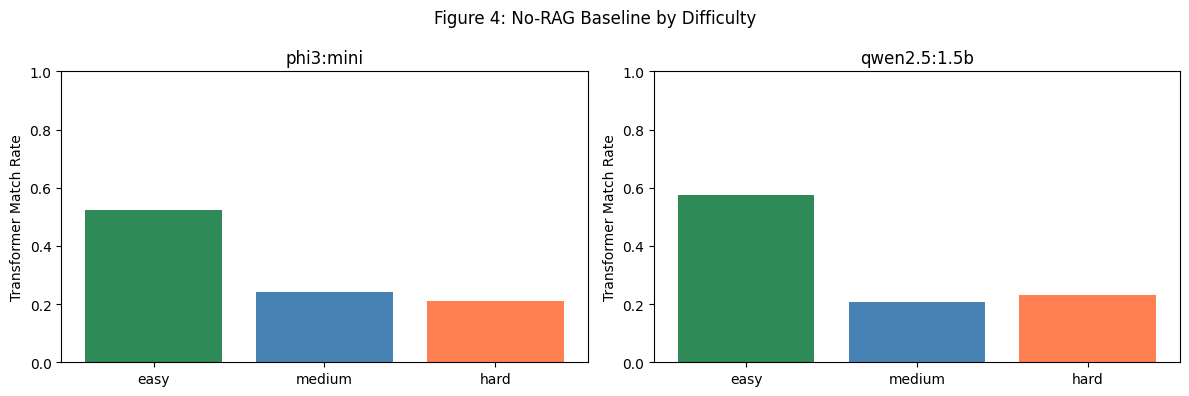

In [8]:
# Figure: baseline comparison by difficulty
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
diffs = ['easy', 'medium', 'hard']

for ax, (model_name, df) in zip(axes, baseline_results.items()):
    scores = [df[df['difficulty'] == d]['transformer_match'].mean() for d in diffs]
    ax.bar(diffs, scores, color=['seagreen', 'steelblue', 'coral'])
    ax.set_title(f'{model_name}')
    ax.set_ylabel('Transformer Match Rate')
    ax.set_ylim(0, 1)

plt.suptitle('Figure 4: No-RAG Baseline by Difficulty')
plt.tight_layout()
plt.savefig('figures/task2_baseline.png', dpi=150)
plt.show()